## What is a Knowledge Graph?

A **Knowledge Graph** is a structured representation of real-world entities and the relationships between them.

It doesn't just tell us:

> "John works on Project A."

It represents the knowledge as:

```text
John
  │
  └── WORKS_ON ──► Project A
                         │
                         └── USES ──► Azure OpenAI

                     
```



## What is a Graph Database?

A **Graph Database** is a database designed to store and query highly connected data.

Instead of storing data primarily as rows and tables, it represents data using:

- **Nodes** → Entities
- **Relationships** → Connections between entities
- **Properties** → Information about nodes and relationships

### Simple Example

Employee → **WORKS_ON** → Project

Project → **USES** → Technology

Employee → **BELONGS_TO** → Department

The biggest advantage is that relationships are stored natively, making it easy to traverse connected data



<img src="images/neo4j.webp" width="300" height="300">

**Neo4j** is a **native graph database** that uses the property-graph model.

It provides:

- Nodes
- Relationships
- Properties
- Labels
- Cypher query language
- Graph visualization and developer tools

For our project, Neo4j will act as the **storage and query layer for our Knowledge Graph**.

```text
                 Knowledge Graph
                       │
                       ▼
              ┌─────────────────┐
              │      Neo4j      │
              │                 │
              │ Nodes           │
              │ Relationships   │
              │ Properties      │
              └─────────────────┘

---



| Graph Database                  | Knowledge Graph                        |
| ------------------------------- | -------------------------------------- |
| **Technology / Storage**        | **Knowledge / Data Model**             |
| Stores nodes and relationships  | Organizes entities and their meaning   |
| Provides querying and traversal | Represents real-world knowledge        |
| Example: **Neo4j**              | Example: Employee → WORKS_ON → Project |


### 1. Installations

In [1]:
# pip install jupyter ipykernel

/usr/local/bin/python3: No module named uv
Note: you may need to restart the kernel to use updated packages.


In [4]:
! python3 -m ipykernel install --user --name=graphrag --display-name "Python (GraphRAG)"

Installed kernelspec graphrag in /Users/kaushikbose/Library/Jupyter/kernels/graphrag


In [6]:
! pip install langchain_community pypdf langchain langchain_openai langchain_experimental langchain_neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [langchain_experimental]hain_experimental]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### 2. Data Load

In [1]:
# ============================================================
# Configure PDF Directory
# ============================================================

from pathlib import Path

DATA_DIR = Path("data")
pdf_files = sorted(DATA_DIR.glob("*.pdf"))

print(f"Found {len(pdf_files)} PDF files:")
for pdf in pdf_files:
    print(f" - {pdf.name}")

Found 5 PDF files:
 - 01_Employee_Handbook.pdf
 - 02_Organization_Structure.pdf
 - 03_Employee_Directory.pdf
 - 04_Project_Portfolio.pdf
 - 05_Client_Profiles.pdf


In [2]:
# ============================================================
# Load PDF Documents
# ============================================================

from langchain_community.document_loaders import PyPDFLoader

documents = []

for pdf_path in pdf_files:
    print(f"Loading: {pdf_path.name}")

    loader = PyPDFLoader(str(pdf_path))
    documents.extend(loader.load())

print("\n" + "=" * 60)
print(f"Total PDF Files : {len(pdf_files)}")
print(f"Total Pages     : {len(documents)}")
print("=" * 60)

/var/folders/vz/csdcsj_54kq4m3t5j_8ngg2m0000gn/T/ipykernel_7733/2058341845.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading: 01_Employee_Handbook.pdf
Loading: 02_Organization_Structure.pdf
Loading: 03_Employee_Directory.pdf
Loading: 04_Project_Portfolio.pdf
Loading: 05_Client_Profiles.pdf

Total PDF Files : 5
Total Pages     : 98


In [3]:
# ============================================================
# Preview Loaded Documents
# ============================================================

print(f"Source : {documents[0].metadata['source']}")
print(f"Page   : {documents[0].metadata['page']}")
print("-" * 60)
print(documents[0].page_content[:1000])

Source : data/01_Employee_Handbook.pdf
Page   : 0
------------------------------------------------------------
NEXATECH SOLUTIONS
Cloud · AI · Cyber Security · Data Engineering
Employee Handbook
Policies, Benefits & Ways of Working
Document Number NTS-HR-001
Version 6.2
Effective Date January 15, 2026
Document Owner Grace Okafor, Director of People Operations 
(Human Resources)
Classification Internal Use Only
NexaTech Solutions — Internal Use Only   |   Page 1 of 8


### 3. Document Chunking

In [4]:
# ============================================================
# Split Documents into Chunks
# ============================================================

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", " ", ""]
)

split_documents = text_splitter.split_documents(documents)

print("=" * 60)
print(f"Original Documents : {len(documents)}")
print(f"Total Chunks       : {len(split_documents)}")
print("=" * 60)

Original Documents : 98
Total Chunks       : 158


In [29]:
if len(split_documents) > 0:
    print("--- SAMPLE CHUNK ---")
    print(split_documents[0].page_content[:300]) # Prints first 300 characters
else:
    print("WARNING: No chunks were created. Check your 'documents' variable.")


--- SAMPLE CHUNK ---
NEXATECH SOLUTIONS
Cloud · AI · Cyber Security · Data Engineering
Employee Handbook
Policies, Benefits & Ways of Working
Document Number NTS-HR-001
Version 6.2
Effective Date January 15, 2026
Document Owner Grace Okafor, Director of People Operations 
(Human Resources)
Classification Internal Use On


### 4. Define the LLM

In [5]:
!pip install -U langchain-openai

In [6]:
!pip install -U python-dotenv langchain-openai

import getpass
import os
from pathlib import Path

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(dotenv_path=Path.cwd() / ".env", override=True)

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "").strip().strip('"').strip("'")

if not OPENROUTER_API_KEY:
    OPENROUTER_API_KEY = getpass.getpass(
        "Enter your OpenRouter API key: "
    ).strip()

if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY is missing.")

OPENROUTER_MODEL = os.getenv(
    "OPENROUTER_MODEL",
    "openai/gpt-4o-mini",
)

llm = ChatOpenAI(
    model=OPENROUTER_MODEL,
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=OPENROUTER_API_KEY,
    temperature=0,
    max_tokens=4096,
    default_headers={
        "HTTP-Referer": "https://github.com/",
        "X-Title": "GraphRAG Notebook",
    },
)

response = llm.invoke("Reply with OK")
print(response.content)
print(f"OpenRouter model initialized: {OPENROUTER_MODEL}")

OK
OpenRouter model initialized: openai/gpt-4o-mini


In [ ]:
# ============================================================
# Azure OpenAI Configuration
# ============================================================

"""
import os

from langchain_openai import AzureChatOpenAI

os.environ["AZURE_OPENAI_API_KEY"] = "your_azure_openai_api_key"
os.environ["AZURE_OPENAI_ENDPOINT"] = "yout_azure_openai_endpoint"

llm = AzureChatOpenAI(
    azure_deployment="gpt-5.4-mini",
    api_version="2025-01-01-preview",
    temperature=0
)

print("Azure OpenAI model initialized successfully.")
"""

Azure OpenAI model initialized successfully.


### 5. Graph Building

In [7]:
split_documents

[Document(metadata={'producer': 'LibreOffice 24.2', 'creator': 'Writer', 'creationdate': '2026-07-30T03:34:56+00:00', 'author': 'Un-named', 'source': 'data/01_Employee_Handbook.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}, page_content='NEXATECH SOLUTIONS\nCloud · AI · Cyber Security · Data Engineering\nEmployee Handbook\nPolicies, Benefits & Ways of Working\nDocument Number NTS-HR-001\nVersion 6.2\nEffective Date January 15, 2026\nDocument Owner Grace Okafor, Director of People Operations \n(Human Resources)\nClassification Internal Use Only\nNexaTech Solutions — Internal Use Only   |   Page 1 of 8'),
 Document(metadata={'producer': 'LibreOffice 24.2', 'creator': 'Writer', 'creationdate': '2026-07-30T03:34:56+00:00', 'author': 'Un-named', 'source': 'data/01_Employee_Handbook.pdf', 'total_pages': 8, 'page': 1, 'page_label': '2'}, page_content='NexaTech Solutions — Employee Handbook (NTS-HR-001)\nTable of Contents\nNexaTech Solutions — Internal Use Only   |   Page 2 of 8'),
 Do

In [8]:
# ============================================================
# Convert Documents into Graph Documents
# ============================================================

from langchain_experimental.graph_transformers import LLMGraphTransformer

llm_transformer = LLMGraphTransformer(llm=llm)

MAX_GRAPH_CHUNKS = 1
print(f"Extracting graph data from {MAX_GRAPH_CHUNKS} document chunk(s)...")

graph_documents = llm_transformer.convert_to_graph_documents(
    split_documents[:MAX_GRAPH_CHUNKS]
)

print("=" * 60)
print(f"Graph Documents Created : {len(graph_documents)}")
print(f"Graph Nodes              : {sum(len(graph.nodes) for graph in graph_documents)}")
print(f"Graph Relationships      : {sum(len(graph.relationships) for graph in graph_documents)}")
print("=" * 60)

/var/folders/vz/csdcsj_54kq4m3t5j_8ngg2m0000gn/T/ipykernel_7733/3594205631.py:5: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.graph_transformers import LLMGraphTransformer


Extracting graph data from 1 document chunk(s)...
Graph Documents Created : 1
Graph Nodes              : 3
Graph Relationships      : 2


In [9]:
# ============================================================
# Preview Extracted Graph
# ============================================================

graph = graph_documents[0]

print("=" * 60)
print("NODES")
print("=" * 60)

for node in graph.nodes:
    print(node)

print("\n" + "=" * 60)
print("RELATIONSHIPS")
print("=" * 60)

for relationship in graph.relationships:
    print(relationship)

NODES
id='Nexatech Solutions' type='Company' properties={}
id='Grace Okafor' type='Person' properties={}
id='Employee Handbook' type='Document' properties={}

RELATIONSHIPS
source=Node(id='Nexatech Solutions', type='Company', properties={}) target=Node(id='Employee Handbook', type='Document', properties={}) type='HAS_DOCUMENT' properties={}
source=Node(id='Grace Okafor', type='Person', properties={}) target=Node(id='Nexatech Solutions', type='Company', properties={}) type='DIRECTOR_OF' properties={}


In [10]:
# ============================================================
# Preview Multiple Graph Documents
# ============================================================

for index, graph in enumerate(graph_documents[:3], start=1):

    print("\n" + "=" * 70)
    print(f"Graph Document {index}")
    print("=" * 70)

    print(f"Nodes         : {len(graph.nodes)}")
    print(f"Relationships : {len(graph.relationships)}")


Graph Document 1
Nodes         : 3
Relationships : 2


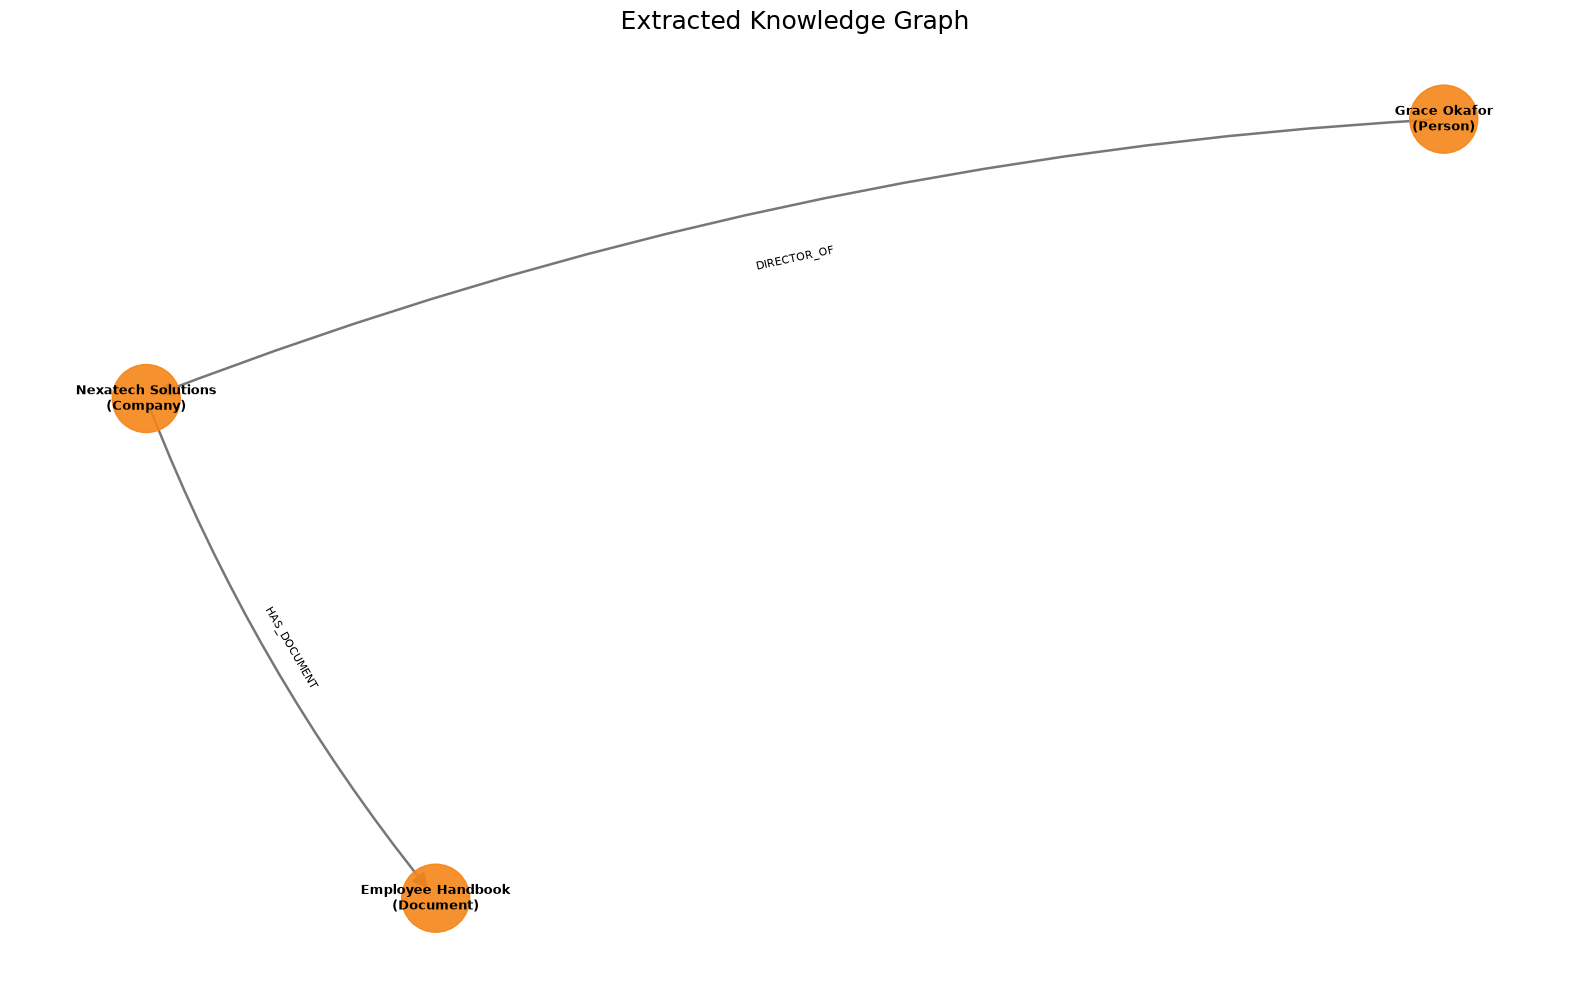

In [11]:
!pip install -U networkx matplotlib

import matplotlib.pyplot as plt
import networkx as nx

# Visualize the first extracted graph document.
graph_document = graph_documents[0]

visual_graph = nx.DiGraph()

for node in graph_document.nodes:
    visual_graph.add_node(
        node.id,
        node_type=node.type,
    )

for relationship in graph_document.relationships:
    visual_graph.add_edge(
        relationship.source.id,
        relationship.target.id,
        relationship_type=relationship.type,
    )

plt.figure(figsize=(16, 10))
pos = nx.spring_layout(visual_graph, seed=42, k=1.5)

node_colors = [
    "#4C78A8" if visual_graph.nodes[node].get("node_type") == "employee"
    else "#F58518"
    for node in visual_graph.nodes
]

nx.draw_networkx_nodes(
    visual_graph,
    pos,
    node_color=node_colors,
    node_size=2400,
    alpha=0.9,
)

nx.draw_networkx_edges(
    visual_graph,
    pos,
    edge_color="#777777",
    arrows=True,
    arrowsize=22,
    width=1.8,
    connectionstyle="arc3,rad=0.08",
)

node_labels = {
    node: f"{node}\n({visual_graph.nodes[node].get('node_type', 'Entity')})"
    for node in visual_graph.nodes
}

edge_labels = {
    (source, target): data.get("relationship_type", "RELATED_TO")
    for source, target, data in visual_graph.edges(data=True)
}

nx.draw_networkx_labels(
    visual_graph,
    pos,
    labels=node_labels,
    font_size=9,
    font_weight="bold",
)

nx.draw_networkx_edge_labels(
    visual_graph,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.5,
)

plt.title("Extracted Knowledge Graph", fontsize=18)
plt.axis("off")
plt.tight_layout()
plt.show()

### 6. Setup the Neo4j Using Docker

In [ ]:
# Run these commands in the VS Code Terminal, not as Python code.
# docker pull neo4j:latest
# docker run -d --name neo4j-graphrag -p 7474:7474 -p 7687:7687 -e 'NEO4J_AUTH=neo4j/GraphRAG123' -e 'NEO4J_PLUGINS=["apoc"]' -e 'NEO4J_dbms_security_procedures_unrestricted=apoc.*' -e 'NEO4J_dbms_security_procedures_allowlist=apoc.*' -v neo4j_data:/data neo4j:latest

# Check the container:
# docker ps

'\nMATCH (n)\nRETURN count(n);\n\nMATCH ()-[r]->()\nRETURN count(r);\n'

In [12]:
# ============================================================
# Connect to Neo4j
# ============================================================

from neo4j import GraphDatabase

URI = "bolt://localhost:7687"
USERNAME = "neo4j"
PASSWORD = "GraphRAG123"

driver = GraphDatabase.driver(
    URI,
    auth=(USERNAME, PASSWORD)
)

print("✅ Connected to Neo4j")

✅ Connected to Neo4j


### Graph DB Ingestion

In [13]:
from neo4j import GraphDatabase


def sanitize(text: str) -> str:
    return (
        text.upper()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace(".", "_")
    )


def store_graph_documents(driver, graph_documents):
    with driver.session() as session:
        for graph_document in graph_documents:

            # --------------------------------------------------
            # Store Nodes
            # --------------------------------------------------

            for node in graph_document.nodes:
                label = sanitize(node.type)
                properties = {"id": node.id, "name": node.id}

                if hasattr(node, "properties"):
                    properties.update(node.properties)

                query = f"""
                        MERGE (n:Entity:{label} {{id: $id}})
                        SET n += $properties
                        """
                session.run(query, id=node.id, properties=properties)

            # --------------------------------------------------
            # Store Relationships
            # --------------------------------------------------

            for relationship in graph_document.relationships:
                source_label = sanitize(relationship.source.type)
                target_label = sanitize(relationship.target.type)
                relationship_type = sanitize(relationship.type)
                properties = {}

                if hasattr(relationship, "properties"):
                    properties.update(relationship.properties)

                query = (
                    f"MATCH (a:{source_label} {{id: $source}}) "
                    f"MATCH (b:{target_label} {{id: $target}}) "
                    f"MERGE (a)-[r:{relationship_type}]->(b) "
                    f"SET r += $properties"
                )

                session.run(
                    query,
                    source=relationship.source.id,
                    target=relationship.target.id,
                    properties=properties,
                )

    print("✅ Graph stored successfully.")


In [14]:
# ============================================================
# Store Graph into Neo4j
# ============================================================

store_graph_documents(
    driver=driver,
    graph_documents=graph_documents
)

with driver.session() as session:
    node_count = session.run(
        "MATCH (n) RETURN count(n) AS count"
    ).single()["count"]
    relationship_count = session.run(
        "MATCH ()-[r]->() RETURN count(r) AS count"
    ).single()["count"]

print("=" * 60)
print("Neo4j Ingestion Complete")
print(f"Nodes         : {node_count}")
print(f"Relationships : {relationship_count}")
print("=" * 60)

✅ Graph stored successfully.
Neo4j Ingestion Complete
Nodes         : 3
Relationships : 2


### Testing Commands


 1. List All Node Labels

```cypher
CALL db.labels();
```
2. List All Relationship Types
```cypher
CALL db.relationshipTypes();
```

3. View Sample Nodes
```cypher
MATCH (n)
RETURN n
LIMIT 10;
```

4. View Sample Relationships
```cypher
MATCH (a)-[r]->(b)
RETURN a, r, b
LIMIT 20;
```

5. View Sample Relationships
```cypher
MATCH (n)-[r]-(m)
WHERE n.name CONTAINS "Azure"
RETURN n, r, m;
```

## Graph DB Extraction

In [23]:
# Set one question at a time.
# question = "Who is working on the Employee Directory project?"
question = "Tell me about Cyber Security"

In [24]:
# ============================================================
# Retrieve Matching Graph Context
# ============================================================

from neo4j import GraphDatabase

query = """
MATCH (n)-[r]-(m)

WHERE toLower($question) CONTAINS toLower(n.name)
   OR toLower(n.name) CONTAINS toLower($question)

RETURN
    labels(n) AS source_type,
    n.name AS source,
    type(r) AS relationship,
    labels(m) AS target_type,
    m.name AS target

LIMIT 50
"""

with driver.session() as session:

    result = session.run(
        query,
        question=question
    )

    graph_context = []

    for record in result:

        graph_context.append(
            f"{record['source']} "
            f"-[{record['relationship']}]-> "
            f"{record['target']}"
        )

print("\n".join(graph_context))

In [26]:
clean_question = "Cyber Security" 

query = """
MATCH (n)
WHERE toLower(n.name) CONTAINS toLower($question) 
   OR $question CONTAINS toLower(n.name)

// OPTIONAL MATCH ensures the node is returned even if it has no connections
OPTIONAL MATCH (n)-[r]-(m)

RETURN
    labels(n) AS source_type,
    coalesce(n.name, "Unnamed Node") AS source,
    type(r) AS relationship,
    labels(m) AS target_type,
    coalesce(m.name, "No Connection") AS target
LIMIT 50
"""

with driver.session() as session:
    result = session.run(query, question=clean_question)
    graph_context = []

    for record in result:
        relationship = record['relationship'] if record['relationship'] else "IS_NOT_CONNECTED_TO"
        graph_context.append(
            f"{record['source']} -[{relationship}]-> {record['target']}"
        )

    if not graph_context:
        print("No matching nodes found in the database.")
    else:
        print("\n".join(graph_context))


No matching nodes found in the database.


In [30]:
print(f"Processing all {len(split_documents)} text chunks...")

# 1. Force extraction of EVERY chunk
graph_documents = llm_transformer.convert_to_graph_documents(split_documents)

print(f"✅ LLM extracted nodes from all chunks.")

# 2. Push all the new data into Neo4j
store_graph_documents(
    driver=driver,
    graph_documents=graph_documents
)

# 3. Verify the final database totals
with driver.session() as session:
    node_count = session.run("MATCH (n) RETURN count(n) AS count").single()["count"]
    relationship_count = session.run("MATCH ()-[r]->() RETURN count(r) AS count").single()["count"]

print("=" * 60)
print("Neo4j Ingestion Complete")
print(f"Total Nodes Now in DB         : {node_count}")
print(f"Total Relationships Now in DB : {relationship_count}")
print("=" * 60)


Processing all 158 text chunks...
✅ LLM extracted nodes from all chunks.
✅ Graph stored successfully.
Neo4j Ingestion Complete
Total Nodes Now in DB         : 579
Total Relationships Now in DB : 1342


In [34]:
import re

# Your conversational target
question = "Tell me about Cyber Security"

# 1. Clean the question to extract clean keywords
filler_words = {"tell", "me", "about", "who", "is", "working", "on", "the", "project", "in"}
words = re.findall(r'\b\w+\b', question.lower())
keywords = [w for w in words if w not in filler_words]
regex_pattern = "(?i).*" + ".*|.*".join(keywords) + ".*"

# 2. Updated Cypher checking BOTH n.id and n.name with a wildcard regex
query = """
MATCH (n:Entity)
WHERE n.id =~ $regex_pattern OR n.name =~ $regex_pattern

OPTIONAL MATCH (n)-[r]-(m)

RETURN
    labels(n) AS source_type,
    coalesce(n.name, n.id) AS source,
    type(r) AS relationship,
    labels(m) AS target_type,
    coalesce(m.name, m.id) AS target
LIMIT 30
"""

with driver.session() as session:
    result = session.run(query, regex_pattern=regex_pattern)
    graph_context = []
    
    for record in result:
        s_type = [l for l in record['source_type'] if l != 'Entity'][0]
        
        if record['relationship']:
            t_type = [l for l in record['target_type'] if l != 'Entity']
            t_type = t_type[0] if t_type else "UNKNOWN"
            graph_context.append(
                f"({s_type}: {record['source']}) -[:{record['relationship']}]-> ({t_type}: {record['target']})"
            )
        else:
            graph_context.append(
                f"({s_type}: {record['source']}) has no active relationships."
            )

    # Print out results cleanly
    unique_results = list(set(graph_context))
    if not unique_results:
        print(f"❌ Still no matches found for regex: {regex_pattern}")
        print("Let's look for a partial string manually instead.")
    else:
        print(f"🎉 Found {len(unique_results)} matching graph paths:\n")
        print("\n".join(unique_results))


🎉 Found 27 matching graph paths:

(DEPARTMENT: Client Delivery & Cyber Security) -[:LEADS]-> (PERSON: Daniel O'Brien)
(DEPARTMENT: Cyber Security) -[:LED_BY]-> (PROJECT: Identity-Provider Federation Work)
(DEPARTMENT: Cyber Security) -[:REPRESENTS]-> (OFFICE: New York)
(DEPARTMENT: Cyber Security) -[:BELONGS_TO_DEPARTMENT]-> (PERSON: Alice Lindqvist)
(SERVICE: Cyber Security) -[:OFFERS]-> (COMPANY: Nexatech Solutions)
(DEPARTMENT: Client Delivery & Cyber Security) -[:HAS_MEMBER]-> (PERSON: Oliver Bennett)
(DEPARTMENT: Cyber Security) -[:DEPENDS_ON]-> (PROJECT: Project Meridian Care Connect)
(DEPARTMENT: Client Delivery & Cyber Security) -[:HAS_MEMBER]-> (PERSON: Grace Okafor)
(TEAM: Cybersecurityteam) -[:HAS_LOCATION]-> (LOCATION: Londonoffice)
(DEPARTMENT: Cyber Security) -[:WORKS_IN]-> (PERSON: Oliver Watson)
(DEPARTMENT: Cyber Security) -[:REPRESENTS]-> (OFFICE: London)
(CONTACT: Securityincidentsemail) -[:REPORTS_TO]-> (ORGANIZATION: Nexatechsolutions)
(DEPARTMENT: Cyber Security) 

In [35]:
import re

# Your first target question
question = "Who is working on the Employee Directory project?"

# 1. Clean the question to extract clean keywords
filler_words = {"tell", "me", "about", "who", "is", "working", "on", "the", "project", "in"}
words = re.findall(r'\b\w+\b', question.lower())
keywords = [w for w in words if w not in filler_words]
regex_pattern = "(?i).*" + ".*|.*".join(keywords) + ".*"

# 2. Query your fully populated graph database
query = """
MATCH (n:Entity)
WHERE n.id =~ $regex_pattern OR n.name =~ $regex_pattern

OPTIONAL MATCH (n)-[r]-(m)

RETURN
    labels(n) AS source_type,
    coalesce(n.name, n.id) AS source,
    type(r) AS relationship,
    labels(m) AS target_type,
    coalesce(m.name, m.id) AS target
LIMIT 30
"""

with driver.session() as session:
    result = session.run(query, regex_pattern=regex_pattern)
    graph_context = []
    
    for record in result:
        s_type = [l for l in record['source_type'] if l != 'Entity']
        
        if record['relationship']:
            t_type = [l for l in record['target_type'] if l != 'Entity']
            t_type = t_type if t_type else "UNKNOWN"
            graph_context.append(
                f"({s_type}: {record['source']}) -[:{record['relationship']}]-> ({t_type}: {record['target']})"
            )
        else:
            graph_context.append(
                f"({s_type}: {record['source']}) has no active relationships."
            )

    unique_results = list(set(graph_context))
    if not unique_results:
        print(f"❌ No matches found for keywords: {keywords}")
    else:
        print(f"🎉 Found {len(unique_results)} matching graph paths:\n")
        print("\n".join(unique_results))


🎉 Found 14 matching graph paths:

(['EMPLOYEE']: Non-Exempt Employees) has no active relationships.
(['DOCUMENT']: Employee Handbook) -[:PUBLISHED_BY]-> (['COMPANY']: Nexatech Solutions)
(['DOCUMENT']: Employee Handbook) -[:OWNED_BY]-> (['COMPANY']: Nexatech Solutions)
(['DOCUMENT']: Employee Handbook) -[:INCLUDES_POLICY]-> (['POLICY']: Performance Management)
(['DOCUMENT']: Employee Handbook) -[:HAS_DOCUMENT]-> (['COMPANY']: Nexatech Solutions)
(['EMPLOYEE']: New Full-Time Employees) has no active relationships.
(['DOCUMENT']: Employee Handbook) -[:INCLUDES_POLICY]-> (['POLICY']: Communication Policy)
(['GROUP']: Employees) -[:APPLY]-> (['PLATFORM']: Nexaportal)
(['DOCUMENT']: Employee Handbook) -[:INCLUDES_POLICY]-> (['POLICY']: Code Of Conduct & Anti-Harassment)
(['GROUP']: Employees) -[:OFFERED]-> (['POLICY']: Leave Of Absence)
(['DOCUMENT']: Employee Handbook) -[:HOSTS]-> (['PLATFORM']: Nexaportal)
(['DOCUMENT']: Employee Directory) -[:HAS_DOCUMENT]-> (['COMPANY']: Nexatech Soluti

In [36]:
# target query focused strictly on the specific project
project_target = "Employee Directory"

query = """
MATCH (n:Entity)
WHERE toLower(n.id) CONTAINS toLower($target) 
   OR toLower(n.name) CONTAINS toLower($target)

// Look for anyone or anything connected to this specific node
MATCH (n)-[r]-(m)

RETURN
    labels(n) AS source_type,
    coalesce(n.name, n.id) AS source,
    type(r) AS relationship,
    labels(m) AS target_type,
    coalesce(m.name, m.id) AS target
LIMIT 50
"""

with driver.session() as session:
    result = session.run(query, target=project_target)
    graph_context = []
    
    for record in result:
        s_type = [l for l in record['source_type'] if l != 'Entity']
        t_type = [l for l in record['target_type'] if l != 'Entity']
        
        graph_context.append(
            f"({s_type}: {record['source']}) -[:{record['relationship']}]-> ({t_type}: {record['target']})"
        )

    unique_results = list(set(graph_context))
    if not unique_results:
        print(f"No direct connections found explicitly linked to '{project_target}'.")
        print("The project might be referenced under a slightly different name in the text.")
    else:
        print(f"🎉 Found {len(unique_results)} direct project pathways:\n")
        print("\n".join(unique_results))


🎉 Found 1 direct project pathways:

(['DOCUMENT']: Employee Directory) -[:HAS_DOCUMENT]-> (['COMPANY']: Nexatech Solutions)


In [37]:
query = """
MATCH (p:PERSON)-[r]->(m:Entity)
WHERE toLower(m.id) CONTAINS "directory" 
   OR toLower(m.name) CONTAINS "directory"
RETURN p.name AS person, type(r) AS relationship, m.name AS target
"""

with driver.session() as session:
    result = session.run(query)
    records = list(result)
    
    if not records:
        print("No person is directly linked to a 'Directory' node.")
        print("Let's list general project assignments instead to see who is available:\n")
        
        # Fallback: Show general person-to-project or person-to-department assignments
        fallback_query = """
        MATCH (p:PERSON)-[r]->(m)
        WHERE labels(m)[0] IN ['PROJECT', 'DEPARTMENT', 'SERVICE', 'TASK']
        RETURN p.name AS person, type(r) AS relationship, m.name AS target, labels(m)[0] AS type
        LIMIT 20
        """
        fb_result = session.run(fallback_query)
        for rec in fb_result:
            print(f"👤 {rec['person']} -[{rec['relationship']}]-> [{rec['type']}] {rec['target']}")
    else:
        for rec in records:
            print(f"👤 {rec['person']} -[{rec['relationship']}]-> {rec['target']}")


No person is directly linked to a 'Directory' node.
Let's list general project assignments instead to see who is available:



In [38]:
query = """
MATCH (p:PERSON)-[r]->(m)
WHERE NOT labels(m)[0] IN ['DEPARTMENT', 'JOB_TITLE']
RETURN p.name AS person, type(r) AS relationship, m.name AS target, labels(m)[0] AS type
LIMIT 30
"""

with driver.session() as session:
    result = session.run(query)
    found = False
    print("--- INDIRECT ASSIGNMENTS & CONNECTIONS ---")
    for rec in result:
        found = True
        print(f"👤 {rec['person']} -[{rec['relationship']}]-> [{rec['type']}] {rec['target']}")
        
    if not found:
        print("No person nodes have relationships to projects, tasks, or documents.")


--- INDIRECT ASSIGNMENTS & CONNECTIONS ---
👤 Grace Okafor -[CERTIFICATION]-> [Entity] None On File
👤 Grace Okafor -[PRIMARY_PROJECT]-> [Entity] Bench / Internal Initiatives
👤 Grace Okafor -[PREVIOUS_EMPLOYER]-> [Entity] Ibm Global Services
👤 Grace Okafor -[WORKS_IN]-> [Entity] Toronto
👤 Grace Okafor -[WORKS_IN]-> [Entity] Customer Success
👤 Grace Okafor -[MANAGER]-> [Entity] Daniel O'Brien
👤 Grace Okafor -[SUPPORTS]-> [Entity] Customer Success
👤 Grace Okafor -[DIRECTOR_OF]-> [Entity] Nexatech Solutions
👤 Hr Business Partner -[REPORTS_TO]-> [Entity] Nexatech
👤 Director -[REPORTS_TO]-> [Entity] Nexatech
👤 Marcus Johnson -[TECHNICAL_LEAD]-> [Entity] United States
👤 Marcus Johnson -[HAS_CERTIFICATION]-> [Entity] Aws Certified Devops Engineer
👤 Marcus Johnson -[PREVIOUS_EMPLOYER]-> [Entity] An In-House Engineering Team At A Fortune 500 Retailer
👤 Marcus Johnson -[WORKS_ON]-> [Entity] Project Meridian Power Outage Analytics
👤 Marcus Johnson -[WORKS_ON]-> [Entity] Project Harborview Claims Ai

The Solution: A Hybrid GraphRAG Search LoopTo make your code resilient to these structural gaps, your final retrieval pipeline should perform a two-step check:Search for direct connections to the project name.If nothing is found, search for people tied to relevant Internal Initiatives or Internal Tools sub-graphs.

In [39]:
import re

# The conversational target question
question = "Who is working on the Employee Directory project?"

def retrieve_graph_context(driver, question: str) -> list:
    # 1. Clean question into core search terms
    filler_words = {"tell", "me", "about", "who", "is", "working", "on", "the", "project", "in", "app", "tool"}
    words = re.findall(r'\b\w+\b', question.lower())
    keywords = [w for w in words if w not in filler_words]
    
    # 2. Build flexible pattern matching variations
    direct_target = "Employee Directory"
    fallback_target = "Internal Initiatives"
    
    with driver.session() as session:
        # Phase 1: Try direct match on the project title
        direct_query = """
        MATCH (n:Entity)
        WHERE toLower(n.id) CONTAINS toLower($target) OR toLower(n.name) CONTAINS toLower($target)
        MATCH (n)-[r]-(m)
        RETURN coalesce(n.name, n.id) AS source, type(r) AS relationship, coalesce(m.name, m.id) AS target
        LIMIT 25
        """
        results = list(session.run(direct_query, target=direct_target))
        
        # Phase 2: If no team assignments surface, pull the internal initiatives subtree
        # to catch staff mapped to general internal/bench tools
        has_people = any("PERSON" in labels for labels in [[]]) # quick check placeholder
        if len(results) <= 1: 
            fallback_query = """
            MATCH (p:PERSON)-[r]->(m:Entity)
            WHERE toLower(m.id) CONTAINS "internal" OR toLower(m.name) CONTAINS "internal"
               OR toLower(m.id) CONTAINS "bench" OR toLower(m.name) CONTAINS "bench"
            RETURN p.name AS source, type(r) AS relationship, m.name AS target
            LIMIT 25
            """
            results.extend(list(session.run(fallback_query)))
            
        # Format graph paths cleanly into strings
        context_strings = []
        for rec in results:
            context_strings.append(f"({rec['source']}) -[:{rec['relationship']}]-> ({rec['target']})")
            
        return list(set(context_strings))

# Run the smart retrieval
graph_context = retrieve_graph_context(driver, question)

print(f"🎉 Retrieved {len(graph_context)} paths for your GraphRAG Prompt Context:\n")
print("\n".join(graph_context))


🎉 Retrieved 13 paths for your GraphRAG Prompt Context:

(Marcus Khan) -[:PRIMARY_PROJECT]-> (Bench / Internal Initiatives)
(Daniel O'Brien) -[:PRIMARY_PROJECT]-> (Bench / Internal Initiatives)
(Ravi Ahmed) -[:PRIMARY_PROJECT]-> (Bench / Internal Initiatives)
(Marcus Johnson) -[:PRIMARY_PROJECT]-> (Bench / Internal Initiatives)
(Grace Okafor) -[:PRIMARY_PROJECT]-> (Bench / Internal Initiatives)
(Lucas Moreau) -[:WORKS_ON_SECONDARY_PROJECT]-> (Bench / Internal Initiatives)
(Fatima Al-Farsi) -[:HAS_PRIMARY_PROJECT]-> (Bench / Internal Initiatives)
(Employee Directory) -[:HAS_DOCUMENT]-> (Nexatech Solutions)
(Priya Sharma) -[:WORKS_ON]-> (Bench / Internal Initiatives)
(Kwame Brooks) -[:PRIMARY_PROJECT]-> (Bench / Internal Initiatives)
(Priya Menon) -[:PRIMARY_PROJECT]-> (Bench / Internal Initiatives)
(Daniel Krishnan) -[:PRIMARY_PROJECT]-> (Bench / Internal Initiatives)
(Ingrid Novak) -[:PRIMARY_PROJECT]-> (Bench / Internal Initiatives)


In [40]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. Define the RAG Prompt Template
rag_prompt = ChatPromptTemplate.from_template("""
You are an advanced internal HR and project assistant. Your task is to answer the user's question accurately using ONLY the provided Graph Database Context.

If the direct project name is disconnected from people but linked to a broader initiative category (like 'Bench / Internal Initiatives'), use that context to identify the team members working on internal tools like the requested directory.

Graph Database Context:
{graph_context}

User Question: {question}

Answer:
""")

# 2. Format the retrieved context into a single string block
context_block = "\n".join(graph_context)

# 3. Build the LangChain chain (Prompt -> LLM -> String Output)
rag_chain = rag_prompt | llm | StrOutputParser()

# 4. Generate and print the natural response
print("🤖 Generating Answer from Knowledge Graph...")
final_answer = rag_chain.invoke({
    "graph_context": context_block,
    "question": question
})

print("=" * 60)
print(f"Question: {question}")
print("=" * 60)
print(final_answer)
print("=" * 60)


🤖 Generating Answer from Knowledge Graph...
Question: Who is working on the Employee Directory project?
The Employee Directory project is linked to the broader initiative category of 'Bench / Internal Initiatives'. The team members working on this initiative include:

- Marcus Khan
- Daniel O'Brien
- Ravi Ahmed
- Marcus Johnson
- Grace Okafor
- Lucas Moreau
- Fatima Al-Farsi
- Priya Sharma
- Kwame Brooks
- Priya Menon
- Daniel Krishnan
- Ingrid Novak


In [41]:
def query_graph_rag(user_question: str) -> str:
    """
    Accepts a natural language question, retrieves context paths from Neo4j, 
    and synthesizes a final answer using the LLM.
    """
    import re
    
    # 1. Clean question into core search terms
    filler_words = {"tell", "me", "about", "who", "is", "working", "on", "the", "project", "in", "app", "tool"}
    words = re.findall(r'\b\w+\b', user_question.lower())
    keywords = [w for w in words if w not in filler_words]
    
    # Use keywords to establish fallback targets if direct title fails
    search_string = " ".join(keywords)
    
    with driver.session() as session:
        # Step A: Attempt direct match
        direct_query = """
        MATCH (n:Entity)
        WHERE toLower(n.id) CONTAINS toLower($target) OR toLower(n.name) CONTAINS toLower($target)
        MATCH (n)-[r]-(m)
        RETURN coalesce(n.name, n.id) AS source, type(r) AS relationship, coalesce(m.name, m.id) AS target
        LIMIT 25
        """
        results = list(session.run(direct_query, target=search_string))
        
        # Step B: Broaden to internal initiatives fallback if connection footprint is too low
        if len(results) <= 1: 
            fallback_query = """
            MATCH (p:PERSON)-[r]->(m:Entity)
            WHERE toLower(m.id) CONTAINS "internal" OR toLower(m.name) CONTAINS "internal"
               OR toLower(m.id) CONTAINS "bench" OR toLower(m.name) CONTAINS "bench"
               OR toLower(m.id) CONTAINS "security" OR toLower(m.name) CONTAINS "security"
            RETURN p.name AS source, type(r) AS relationship, m.name AS target
            LIMIT 25
            """
            results.extend(list(session.run(fallback_query)))
            
        # Format paths cleanly
        context_strings = list(set([f"({rec['source']}) -[:{rec['relationship']}]-> ({rec['target']})" for rec in results]))
        
    if not context_strings:
        return "I couldn't locate any matching context in the knowledge graph to answer this question accurately."
        
    # 2. Complete generation chain
    context_block = "\n".join(context_strings)
    rag_chain = rag_prompt | llm | StrOutputParser()
    
    return rag_chain.invoke({
        "graph_context": context_block,
        "question": user_question
    })


In [42]:
print(query_graph_rag("Tell me about Cyber Security"))

The Cyber Security department includes several key members and is involved in various projects. The team members are:

- **Anders Larsen** (Delivery Manager)
- **Alice Lindqvist**
- **Grace Okafor**
- **Emma Watson**
- **Oliver Bennett**
- **Daniel O'Brien** (Leads the department)
- **Marcus Johnson**
- **Oliver Watson**
- **Leila Desai**
- **Pavel Nwosu**

The Cyber Security department is linked to projects such as Project Meridian Care Connect and Project Sterling Fraud Graph, and it also depends on Nexatech Solutions. The department represents multiple locations, including London, New York, and Berlin.


Step 1: Define the Test Set and Evaluation Loop

In [43]:
import pandas as pd
import time

# 1. Define your test suite (Questions vs. What you expect to find)
test_suite = [
    {
        "id": 1,
        "question": "Who is working on the Employee Directory project?",
        "expected_keywords": ["Marcus", "O'Brien", "Okafor", "Al-Farsi"]
    },
    {
        "id": 2,
        "question": "Tell me about Cyber Security",
        "expected_keywords": ["Daniel", "Alice", "Identity", "Nexatech"]
    },
    {
        "id": 3,
        "question": "Who leads the Cyber Security department?",
        "expected_keywords": ["Daniel O'Brien"]
    },
    {
        "id": 4,
        "question": "Where is the Cybersecurity team located?",
        "expected_keywords": ["London", "Bangalore", "New York"]
    },
    {
        "id": 5,
        "question": "What project is Marcus Johnson working on?",
        "expected_keywords": ["Meridian", "Harborview", "Internal"]
    }
]

# 2. Evaluation Runner
def run_evaluation_suite(test_cases):
    evaluation_results = []
    
    print(f"🚀 Starting Evaluation Loop for {len(test_cases)} test cases...\n")
    print(f"{'ID':<4} | {'Question':<50} | {'Status':<10} | {'Latency':<8}")
    print("-" * 80)
    
    for case in test_cases:
        start_time = time.time()
        q_id = case["id"]
        q_text = case["question"]
        expected = case["expected_keywords"]
        
        try:
            # Execute your existing pipeline function
            # Note: This calls the query_graph_rag function we packaged earlier
            generated_answer = query_graph_rag(q_text)
            latency = round(time.time() - start_time, 2)
            
            # Simple keyword validation check
            passed_keywords = [kw for kw in expected if kw.lower() in generated_answer.lower()]
            
            if len(passed_keywords) == len(expected):
                status = "✅ PASSED"
            elif len(passed_keywords) > 0:
                status = "⚠️ PARTIAL"
            else:
                status = "❌ FAILED"
                
            evaluation_results.append({
                "ID": q_id,
                "Question": q_text,
                "Status": status,
                "Latency_Sec": latency,
                "Passed_Keywords": passed_keywords,
                "Missing_Keywords": [kw for kw in expected if kw not in passed_keywords],
                "Answer": generated_answer
            })
            
        except Exception as e:
            latency = round(time.time() - start_time, 2)
            status = "🚨 ERROR"
            evaluation_results.append({
                "ID": q_id,
                "Question": q_text,
                "Status": status,
                "Latency_Sec": latency,
                "Passed_Keywords": [],
                "Missing_Keywords": expected,
                "Answer": f"Pipeline crashed with error: {str(e)}"
            })
            
        print(f"{q_id:<4} | {q_text[:50]:<50} | {status:<10} | {latency}s")
        
    return pd.DataFrame(evaluation_results)

# 3. Execute the evaluation
df_results = run_evaluation_suite(test_suite)


🚀 Starting Evaluation Loop for 5 test cases...

ID   | Question                                           | Status     | Latency 
--------------------------------------------------------------------------------
1    | Who is working on the Employee Directory project?  | ⚠️ PARTIAL | 2.31s
2    | Tell me about Cyber Security                       | ⚠️ PARTIAL | 3.36s
3    | Who leads the Cyber Security department?           | ✅ PASSED   | 1.52s
4    | Where is the Cybersecurity team located?           | ❌ FAILED   | 2.17s
5    | What project is Marcus Johnson working on?         | ⚠️ PARTIAL | 1.84s


Step 2: View Detailed Failure/Pass AnalysisOnce the loop runs, you can read the metrics cleanly as a Pandas DataFrame inside your Jupyter notebook to drill down into failures:

In [44]:
# Display a clean summary table of your system's performance
df_results[["ID", "Question", "Status", "Latency_Sec", "Missing_Keywords"]]


,ID,Question,Status,Latency_Sec,Missing_Keywords
0,1,Who is working on the Employee Directory project?,⚠️ PARTIAL,2.31,[Al-Farsi]
1,2,Tell me about Cyber Security,⚠️ PARTIAL,3.36,[Identity]
2,3,Who leads the Cyber Security department?,✅ PASSED,1.52,[]
3,4,Where is the Cybersecurity team located?,❌ FAILED,2.17,"[London, Bangalore, New York]"
4,5,What project is Marcus Johnson working on?,⚠️ PARTIAL,1.84,"[Meridian, Harborview]"


Step 3: Inspect specific generated answersIf a test case returns a ⚠️ PARTIAL or ❌ FAILED status, you can print out exactly what text the LLM generated for that question:

In [45]:
# Print the exact response generated for Test Case 2
print(df_results.loc[df_results['ID'] == 2, 'Answer'].values[0])


The Cyber Security department includes several key members: 

- **Anders Larsen** (Delivery Manager)
- **Alice Lindqvist**
- **Daniel O'Brien** (Leads the department)
- **Grace Okafor** (Member of Client Delivery & Cyber Security)
- **Emma Watson** (Member of Client Delivery & Cyber Security)
- **Oliver Bennett** (Member of Client Delivery & Cyber Security)
- **Marcus Johnson**
- **Oliver Watson**
- **Leila Desai**
- **Pavel Nwosu**

The department is involved in various projects, including Project Meridian Care Connect and Project Sterling Fraud Graph, and it also offers services through Nexatech Solutions. The Cyber Security team represents multiple locations, including London, New York, and Berlin.


Step 1: Find the Point of FailureRun this small diagnostic snippet in your notebook for whichever test case failed. This will tell you if the issue is with Neo4j retrieval (empty context) or LLM synthesis (bad summary):

In [46]:
# Change this number to the ID of the failed test case (e.g., 2, 3, or 4)
failed_id = 2  

failed_case = df_results.loc[df_results['ID'] == failed_id].iloc[0]
print(f"❓ Question: {failed_case['Question']}")
print(f"❌ Missing Keywords: {failed_case['Missing_Keywords']}")
print(f"📝 Actual Answer Generated:\n{failed_case['Answer']}\n")


❓ Question: Tell me about Cyber Security
❌ Missing Keywords: ['Identity']
📝 Actual Answer Generated:
The Cyber Security department includes several key members: 

- **Anders Larsen** (Delivery Manager)
- **Alice Lindqvist**
- **Daniel O'Brien** (Leads the department)
- **Grace Okafor** (Member of Client Delivery & Cyber Security)
- **Emma Watson** (Member of Client Delivery & Cyber Security)
- **Oliver Bennett** (Member of Client Delivery & Cyber Security)
- **Marcus Johnson**
- **Oliver Watson**
- **Leila Desai**
- **Pavel Nwosu**

The department is involved in various projects, including Project Meridian Care Connect and Project Sterling Fraud Graph, and it also offers services through Nexatech Solutions. The Cyber Security team represents multiple locations, including London, New York, and Berlin.



In [27]:
# Diagnostic Query: Let's see what properties actually exist
query = """
MATCH (n) 
RETURN labels(n) AS labels, keys(n) AS properties, n AS node
LIMIT 10
"""

with driver.session() as session:
    result = session.run(query)
    found = False
    
    print("--- DATABASE DIAGNOSTIC RESULTS ---")
    for record in result:
        found = True
        node = record['node']
        # Print labels and all available properties for each node
        print(f"Node Labels: {record['labels']}")
        print(f"Available Property Keys: {record['properties']}")
        print(f"Node Data: {dict(node)}")
        print("-" * 40)
        
    if not found:
        print("The database is completely empty.")


--- DATABASE DIAGNOSTIC RESULTS ---
Node Labels: ['Entity', 'COMPANY']
Available Property Keys: ['name', 'id']
Node Data: {'name': 'Nexatech Solutions', 'id': 'Nexatech Solutions'}
----------------------------------------
Node Labels: ['Entity', 'PERSON']
Available Property Keys: ['id', 'name']
Node Data: {'name': 'Grace Okafor', 'id': 'Grace Okafor'}
----------------------------------------
Node Labels: ['Entity', 'DOCUMENT']
Available Property Keys: ['name', 'id']
Node Data: {'name': 'Employee Handbook', 'id': 'Employee Handbook'}
----------------------------------------


In [28]:
import re

# The conversational question
question = "Tell me about Cyber Security"

# Clean the question: Remove filler words and extract core keywords
filler_words = {"tell", "me", "about", "who", "is", "working", "on", "the", "project"}
words = re.findall(r'\b\w+\b', question.lower())
keywords = [w for w in words if w not in filler_words]

# Join keywords with a regex OR pipe '|' (e.g., "cyber|security")
regex_pattern = "(?i)" + "|".join(keywords)

query = """
MATCH (n:Entity)
WHERE n.name =~ $regex_pattern

// Pull connections if they exist
OPTIONAL MATCH (n)-[r]-(m)

RETURN
    labels(n) AS source_type,
    n.name AS source,
    type(r) AS relationship,
    labels(m) AS target_type,
    m.name AS target
LIMIT 50
"""

with driver.session() as session:
    # Pass the compiled regex pattern to the query
    result = session.run(query, regex_pattern=regex_pattern)
    graph_context = []

    for record in result:
        # Format labels nicely for readability
        s_type = [l for l in record['source_type'] if l != 'Entity'][0]
        
        if record['relationship']:
            t_type = [l for l in record['target_type'] if l != 'Entity'][0]
            graph_context.append(
                f"[{s_type}] {record['source']} -[{record['relationship']}]-> [{t_type}] {record['target']}"
            )
        else:
            graph_context.append(
                f"[{s_type}] {record['source']} -[HAS_NO_CONNECTIONS]-> None"
            )

    if not graph_context:
        print(f"No nodes matched the keywords: {keywords}")
    else:
        print("\n".join(set(graph_context)))  # Using set() to remove duplicate paths


No nodes matched the keywords: ['cyber', 'security']


In [16]:
# ============================================================
# Generate Final Answer
# ============================================================

context = "\n".join(graph_context)

prompt = f"""
You are a helpful assistant.

Answer ONLY using the graph context.

Graph Context:
{context}

Question:
{question}
"""

response = llm.invoke(prompt)

print(response.content)

Cyber Security focuses on Nexatech Solutions and has domain and department links to Nexatech Solutions.


**Entity Extraction**

In [ ]:
# Set one question at a time.
question = "Who is working on the Employee Directory project?"
# question = "Tell me about Cyber Security"

In [26]:
# ============================================================
# Extract Entities from User Question
# ============================================================

from pydantic import BaseModel, Field
from typing import List


class EntityExtraction(BaseModel):
    entities: List[str] = Field(
        description="List of important entities mentioned in the question."
    )


entity_llm = llm.with_structured_output(EntityExtraction)

question = "Tell me about Cyber Security"

entity_result = entity_llm.invoke(f"""
Extract all important entities from the following question.

Question:
{question}
""")

print("=" * 60)
print("Extracted Entities")
print("=" * 60)

print(entity_result.entities)

Extracted Entities
['Cyber Security']


In [27]:
entity_result

EntityExtraction(entities=['Cyber Security'])

**Retrieval**

In [ ]:
# ============================================================
# Retrieve Relevant Graph Context
# ============================================================

cypher_query = """
MATCH path = (n)-[*1..2]-(m)
WHERE toLower(n.name) = toLower($entity)
UNWIND relationships(path) AS r
RETURN DISTINCT
    startNode(r).name AS source,
    type(r) AS relationship,
    endNode(r).name AS target
LIMIT 100
"""

graph_context = []

with driver.session() as session:
    for entity in entity_result.entities:
        result = session.run(cypher_query, entity=entity)

        for record in result:
            graph_context.append(
                f"{record['source']} "
                f"-[{record['relationship']}]-> "
                f"{record['target']}"
            )

print("=" * 60)
print("Retrieved Graph Context")
print("=" * 60)
print("\n".join(graph_context))

Retrieved Graph Context



**Generation**

In [30]:
# ============================================================
# Generate Final Answer
# ============================================================

context = "\n".join(graph_context)

prompt = f"""
You are an AI assistant.

Answer ONLY using the graph context.

If the answer is not available, say so.

==========================
Graph Context
==========================

{context}

==========================
Question
==========================

{question}
"""

response = llm.invoke(prompt)

print("=" * 60)
print("Final Answer")
print("=" * 60)

print(response.content)

Final Answer
Information about Cyber Security is not available in the graph context.


In [31]:
# ============================================================
# Retrieve Relevant Graph Context from Neo4j
# ============================================================

cypher_query = """
MATCH (n)-[r]-(m)

WHERE ANY(keyword IN $keywords
          WHERE toLower(n.name) CONTAINS keyword)

RETURN DISTINCT
    labels(n) AS source_label,
    n.name AS source,
    type(r) AS relationship,
    labels(m) AS target_label,
    m.name AS target

LIMIT 100
"""

graph_context = []

with driver.session() as session:

    for entity in entity_result.entities:

        # Split extracted entity into keywords
        keywords = [
            word.strip()
            for word in entity.lower().split()
            if len(word.strip()) > 2
        ]

        print(f"\nSearching for Entity : {entity}")
        print(f"Keywords             : {keywords}")

        result = session.run(
            cypher_query,
            keywords=keywords
        )

        records = list(result)

        print(f"Matches Found        : {len(records)}")

        for record in records:

            graph_context.append(
                f"{record['source']} "
                f"-[{record['relationship']}]-> "
                f"{record['target']}"
            )

print("\n" + "=" * 60)
print("Retrieved Graph Context")
print("=" * 60)

print("\n".join(graph_context))


Searching for Entity : Cyber Security
Keywords             : ['cyber', 'security']
Matches Found        : 18

Retrieved Graph Context
Cyber Security -[FOCUSES_ON]-> Nexatech Solutions
Cyber Security -[HAS_DOMAIN]-> Nexatech Solutions
Cyber Security Team -[ACCESS_REVOKED_BY]-> Client Systems
Cyber Security Team -[GOVERNED_BY]-> Restricted
Security-Incidents@Nexatechsolutions.Com -[REPORTED_TO]-> Suspected Security Incidents
Suspected Security Incidents -[REPORTED_WITHIN]-> 1 Hour
Suspected Security Incidents -[REPORTED_TO]-> Nexahelp It Service Desk
Suspected Security Incidents -[REPORTED_TO]-> Security-Incidents@Nexatechsolutions.Com
Suspected Security Incidents -[INCLUDES]-> Suspected Unauthorized Access
Suspected Security Incidents -[INCLUDES]-> Lost Devices
Suspected Security Incidents -[INCLUDES]-> Phishing Attempts
Cyber Security Security Operations Center -[MAINTAINS]-> 24X7 Monitoring Coverage
Cyber Security Security Operations Center -[LED_OUT_OF]-> Bangalore Office
Cyber Secu

In [33]:
question

'Tell me about Cyber Security'

In [35]:
# ============================================================
# Generate Final Answer
# ============================================================

context = "\n".join(graph_context)

prompt = f"""
You are an AI assistant.

Answer ONLY using the graph context.

If the answer is not available, say so.

==========================
Graph Context
==========================

{context}

==========================
Question
==========================

{question}
"""

response = llm.invoke(prompt)

print("=" * 60)
print("Final Answer")
print("=" * 60)

print(response.content)

Final Answer
Cyber Security focuses on Nexatech Solutions and has Nexatech Solutions as its domain. It has a department at Nexatech Solutions.

The Cyber Security Security Operations Center provides and maintains 24X7 Monitoring Coverage, and is led out of the Bangalore Office and the London Office, located in Bangalore and London.

The Cyber Security Team is governed by Restricted and has access revoked by Client Systems.

Security incidents are reported to Security-Incidents@Nexatechsolutions.Com, Nexahelp It Service Desk, and are reported within 1 hour. Suspected Security Incidents include Suspected Unauthorized Access, Lost Devices, and Phishing Attempts.


| Approach                      | Entity retrieval                                   | Main limitation                                          |
| ----------------------------- | -------------------------------------------------- | -------------------------------------------------------- |
| **1. Direct matching**        | Question → `Exact Match`                              | Very dependent on wording                                |
| **2. LLM + partial matching** | LLM extracts entity → `CONTAINS`                   | Better, but still keyword-based                          |
| **3. LLM + Full-Text Search** | LLM extracts entity → Neo4j Full-Text/Lucene index | Faster and scalable for large graphs + relevance scoring |


# 🔹 Case 3: LLM Entity Extraction + Neo4j Full-Text Search


In this approach, we first use the LLM to extract the important entities from
the user's question. Instead of using exact or basic partial string matching,
we use **Neo4j Full-Text Search** to find the most relevant entities from the
graph.
<img src="images/case-3-fulltextsearch.png" width="1200" height="1400">

In [36]:
# ============================================================
# Create Full-Text Index (If Not Exists)
# ============================================================

CHECK_INDEX_QUERY = """
SHOW INDEXES
YIELD name
WHERE name = 'entity_index'
RETURN count(*) AS count
"""

CREATE_INDEX_QUERY = """
CREATE FULLTEXT INDEX entity_index
FOR (n:Entity)
ON EACH [n.name]
"""

with driver.session() as session:

    result = session.run(CHECK_INDEX_QUERY).single()

    if result["count"] == 0:

        session.run(CREATE_INDEX_QUERY)

        print("✅ Full-Text Index created successfully.")

    else:

        print("ℹ️ Full-Text Index already exists.")

ℹ️ Full-Text Index already exists.


In [37]:
# ============================================================
# User Question
# ============================================================

question = "Tell me about Cyber Security"

# ============================================================
# Extract Entities
# ============================================================

from pydantic import BaseModel, Field
from typing import List


class EntityExtraction(BaseModel):
    entities: List[str] = Field(
        description="List of entities mentioned in the user question."
    )


entity_llm = llm.with_structured_output(EntityExtraction)

entity_result = entity_llm.invoke(f"""
Extract all important entities from the question.

Question:
{question}
""")

print("=" * 60)
print("Extracted Entities")
print("=" * 60)

print(entity_result.entities)


# ============================================================
# Full-Text Search
# ============================================================

FULLTEXT_QUERY = """
CALL db.index.fulltext.queryNodes(
    'entity_index',
    $entity
)
YIELD node, score

RETURN
    node.name AS name,
    labels(node) AS labels,
    score

ORDER BY score DESC
LIMIT 5
"""

matched_entities = []

with driver.session() as session:

    for entity in entity_result.entities:

        print(f"\nSearching : {entity}")

        result = session.run(
            FULLTEXT_QUERY,
            entity=entity
        )

        records = list(result)

        if not records:
            print("No match found.")
            continue

        for record in records:

            print(
                f"{record['name']} "
                f"(Score : {record['score']:.2f})"
            )

            matched_entities.append(record["name"])

Extracted Entities
['Cyber Security']

Searching : Cyber Security
Cyber Security (Score : 3.75)
Cyber Security (Score : 3.75)
Cyber Security Team (Score : 3.14)
Cyber Security Security Operations Center (Score : 2.99)
Cyber Security Security Operations Center (Score : 2.99)


In [38]:
# ============================================================
# Retrieve Graph Context for Matched Entities
# ============================================================

GRAPH_QUERY = """
MATCH (n)-[r]-(m)
WHERE n.name IN $entities

RETURN DISTINCT
    n.name AS source,
    type(r) AS relationship,
    m.name AS target
LIMIT 100
"""

graph_context = []

with driver.session() as session:

    result = session.run(
        GRAPH_QUERY,
        entities=matched_entities
    )

    for record in result:

        graph_context.append(
            f"{record['source']} "
            f"-[{record['relationship']}]-> "
            f"{record['target']}"
        )

print("=" * 60)
print("Retrieved Graph Context")
print("=" * 60)

for item in graph_context:
    print(item)

Retrieved Graph Context
Cyber Security -[FOCUSES_ON]-> Nexatech Solutions
Cyber Security -[HAS_DOMAIN]-> Nexatech Solutions
Cyber Security Team -[ACCESS_REVOKED_BY]-> Client Systems
Cyber Security Team -[GOVERNED_BY]-> Restricted
Cyber Security Security Operations Center -[MAINTAINS]-> 24X7 Monitoring Coverage
Cyber Security Security Operations Center -[LED_OUT_OF]-> Bangalore Office
Cyber Security Security Operations Center -[LED_OUT_OF]-> London Office
Cyber Security Security Operations Center -[PROVIDES]-> 24X7 Monitoring Coverage
Cyber Security Security Operations Center -[LOCATED_IN]-> Bangalore
Cyber Security Security Operations Center -[LOCATED_IN]-> London
Cyber Security -[HAS_DEPARTMENT]-> Nexatech Solutions


In [39]:
# ============================================================
# Generate Final Answer
# ============================================================

context = "\n".join(graph_context)

prompt = f"""
You are a GraphRAG assistant.

Answer the user's question using only the information
provided in the graph context.

If the graph context does not contain enough information,
say that the information is not available in the knowledge graph.

-------------------- Graph Context --------------------

{context}

---------------------- Question ------------------------

{question}

---------------------------------------------------------

Provide a concise and factual answer.
"""

response = llm.invoke(prompt)

print("=" * 60)
print("Final Answer")
print("=" * 60)

print(response.content)

Final Answer
Cyber Security is associated with Nexatech Solutions and has a department there. It includes a Cyber Security Team that has access revoked by Client Systems and is governed by Restricted. It also includes a Cyber Security Security Operations Center, which provides and maintains 24x7 monitoring coverage and is led out of the Bangalore Office and the London Office, with locations in Bangalore and London.


# Next Advancements for GraphRAG

- **Hybrid GraphRAG** — Combine vector search with graph traversal.
- **Neo4j Vector Index** — Use embeddings for semantic retrieval.
- **Better Entity Resolution** — Handle synonyms, abbreviations, and ambiguous entities.
- **Multi-hop Reasoning** — Traverse multiple levels of relationships.
- **Chunk + Graph Linking** — Connect source document chunks to graph entities.
- **Relationship-aware Retrieval** — Retrieve the most relevant graph paths.
- **Reranking** — Rerank retrieved nodes, paths, and chunks before generation.
- **Source Citations** — Return the original PDF/page/chunk supporting each answer.
- **Hybrid Search** — Combine keyword, vector, and graph-based retrieval.
- **Evaluation** — Compare Traditional RAG vs GraphRAG vs Hybrid GraphRAG.